In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
car_data = pd.read_csv('/content/car_age_price (1).csv')

In [5]:
car_data.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [6]:
car_data.shape

(112, 2)

In [7]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


# Missing value

In [8]:
car_data.isna().sum()

,0
Year,0
Price,0


# Outlier handling

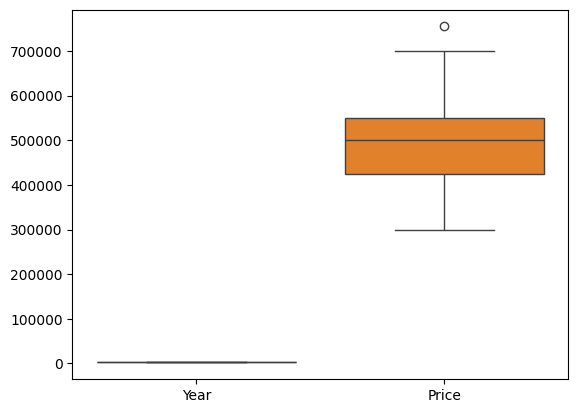

In [9]:
sns.boxplot(car_data)
plt.show()

In [10]:
# Price
q1 = car_data['Price'].quantile(0.25)
q3 = car_data['Price'].quantile(0.75)

print(f'Q1 = {q1}\nQ3 = {q3}')

iqr = q3 - q1

up_lim_Price = q3 + (1.5 * iqr)
low_lim_Price = q1 - (1.5 * iqr)

print(f'IQR = {iqr}\nUp_lim = {up_lim_Price}\nLow_lim = {low_lim_Price}')

Q1 = 423750.0
Q3 = 550000.0
IQR = 126250.0
Up_lim = 739375.0
Low_lim = 234375.0


In [11]:
outliers = car_data[(car_data['Price'] > up_lim_Price) | (car_data['Price'] < low_lim_Price)]
outliers

,Year,Price
1,2019,755000


In [12]:
car_data = car_data.drop(outliers.index)

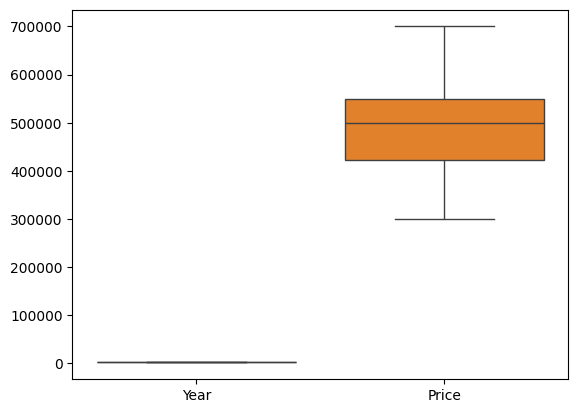

In [13]:
sns.boxplot(car_data)
plt.show()

# Feature Target Split

In [14]:
x = car_data[['Year']]
y = car_data['Price']

# Train Test Split

In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Linear Regression

In [16]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
model = lr.fit(x_train,y_train)
y_pred = model.predict(x_test)

In [17]:
#using MSR, r2_score matrices for model evaluation
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
print(mean_squared_error(y_test,y_pred))
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

2360736941.0488067
0.7087665874512326
37050.25925992429


In [18]:
from sklearn.linear_model import Lasso
lasso = Lasso(alpha=1.0)
model1 = lasso.fit(x_train, y_train)
y_pred = model1.predict(x_test)

from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))
print(mean_absolute_error(y_test, y_pred))


2360749599.6382856
0.7087650258184441
37050.4202958475


In [19]:
# Both model give almost same efficiency

In [20]:
a = pd.DataFrame({"Year": [2022]})
predicted_price = model.predict(a)
print(f"Predicted Price: {predicted_price}")

Predicted Price: [704536.23267838]
